# Volatility Targeting Strategies

Comparison between:
1. **Buy & Hold**: Direct investment in the index
2. **Target Vol 5%**: Position scaled to maintain 5% target volatility
3. **Target Vol 10%**: Position scaled to maintain 10% target volatility

## Strategy Mechanics

The **volatility targeting** strategy scales the position based on recent realized volatility:

$$
\text{Position}_t = \frac{\sigma_{\text{target}}}{\sigma_{\text{realized},t}}
$$

Where:
- $\sigma_{\text{target}}$ is the target volatility (e.g., 5% or 10%)
- $\sigma_{\text{realized},t}$ is the realized volatility over the last N days

**Effect**: 
- When volatility is **low** → increase exposure
- When volatility is **high** → reduce exposure


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")


Libraries loaded successfully


## 1. Load Data


In [ ]:
# Load price data
raw_price_tr_df = pd.read_excel('data/data.xlsx', sheet_name='prices_tr')
dividends_df = pd.read_excel('data/data.xlsx', sheet_name='dividends')
riskfree_df = pd.read_excel('data/data.xlsx', sheet_name='riskfree')

# Merge
price_df = raw_price_tr_df.merge(dividends_df, on='date', how='inner').merge(riskfree_df, on='date', how='inner')
price_df['date'] = pd.to_datetime(price_df['date'], format='%d/%m/%y').dt.date
price_df.dropna(inplace=True)
price_df = price_df.sort_values('date').reset_index(drop=True)

# Calculate returns
price_df['return'] = price_df['close'].pct_change()

print(f"Data loaded: {len(price_df)} days")
print(f"Date range: {price_df['date'].min()} to {price_df['date'].max()}")
print(f"Initial price: ${price_df['close'].iloc[0]:.2f}")
print(f"Final price: ${price_df['close'].iloc[-1]:.2f}")


Data loaded: 4031 days
Date range: 2010-01-04 to 2025-09-30
Initial price: $4781.32
Final price: $13448.66


## 2. Calculate Realized Volatility

Calculate realized volatility on a rolling 21-day window (~1 month).


In [ ]:
# Parameters
VOL_WINDOW = 21  # Rolling window for realized vol (21 trading days ~ 1 month)
TARGET_VOL_5 = 0.05  # 5% annualized
TARGET_VOL_10 = 0.10  # 10% annualized
TRADING_DAYS = 252  # Annualization factor

# Calculate realized volatility (annualized)
price_df['realized_vol'] = price_df['return'].rolling(window=VOL_WINDOW).std() * np.sqrt(TRADING_DAYS)

# Calculate positions for volatility targeting
price_df['position_5pct'] = TARGET_VOL_5 / price_df['realized_vol']
price_df['position_10pct'] = TARGET_VOL_10 / price_df['realized_vol']

# Cap positions at reasonable levels (e.g., max 3x leverage)
MAX_LEVERAGE = 3.0
price_df['position_5pct'] = price_df['position_5pct'].clip(upper=MAX_LEVERAGE)
price_df['position_10pct'] = price_df['position_10pct'].clip(upper=MAX_LEVERAGE)

# Calculate strategy returns (lagged position to avoid look-ahead bias)
price_df['position_5pct_lag'] = price_df['position_5pct'].shift(1)
price_df['position_10pct_lag'] = price_df['position_10pct'].shift(1)

price_df['return_5pct'] = price_df['return'] * price_df['position_5pct_lag']
price_df['return_10pct'] = price_df['return'] * price_df['position_10pct_lag']

# Drop NaN rows (due to rolling window)
price_df_clean = price_df.dropna().copy()

print(f"\nClean data: {len(price_df_clean)} days (after removing initial {VOL_WINDOW} days for vol calculation)")
print(f"\nRealized Vol Statistics:")
print(f"  Min: {price_df_clean['realized_vol'].min()*100:.2f}%")
print(f"  Max: {price_df_clean['realized_vol'].max()*100:.2f}%")
print(f"  Mean: {price_df_clean['realized_vol'].mean()*100:.2f}%")
print(f"  Median: {price_df_clean['realized_vol'].median()*100:.2f}%")



Clean data: 4009 days (after removing initial 21 days for vol calculation)

Realized Vol Statistics:
  Min: 4.69%
  Max: 77.93%
  Mean: 17.89%
  Median: 15.87%


## 3. Calculate Cumulative Performance


In [ ]:
# Calculate cumulative returns (base 100)
price_df_clean['cumret_index'] = (1 + price_df_clean['return']).cumprod() * 100
price_df_clean['cumret_5pct'] = (1 + price_df_clean['return_5pct']).cumprod() * 100
price_df_clean['cumret_10pct'] = (1 + price_df_clean['return_10pct']).cumprod() * 100

# Calculate final statistics
total_return_index = (price_df_clean['cumret_index'].iloc[-1] / 100 - 1) * 100
total_return_5pct = (price_df_clean['cumret_5pct'].iloc[-1] / 100 - 1) * 100
total_return_10pct = (price_df_clean['cumret_10pct'].iloc[-1] / 100 - 1) * 100

# Calculate realized volatilities
realized_vol_index = price_df_clean['return'].std() * np.sqrt(TRADING_DAYS) * 100
realized_vol_5pct = price_df_clean['return_5pct'].std() * np.sqrt(TRADING_DAYS) * 100
realized_vol_10pct = price_df_clean['return_10pct'].std() * np.sqrt(TRADING_DAYS) * 100

# Sharpe ratios (assuming 0% risk-free rate for simplicity)
sharpe_index = (price_df_clean['return'].mean() * TRADING_DAYS) / (price_df_clean['return'].std() * np.sqrt(TRADING_DAYS))
sharpe_5pct = (price_df_clean['return_5pct'].mean() * TRADING_DAYS) / (price_df_clean['return_5pct'].std() * np.sqrt(TRADING_DAYS))
sharpe_10pct = (price_df_clean['return_10pct'].mean() * TRADING_DAYS) / (price_df_clean['return_10pct'].std() * np.sqrt(TRADING_DAYS))

print("\n" + "="*60)
print("PERFORMANCE SUMMARY")
print("="*60)
print(f"\n{'Strategy':<25} {'Total Return':<15} {'Ann. Vol':<15} {'Sharpe'}")
print("-"*60)
print(f"{'Index (Buy & Hold)':<25} {total_return_index:>13.2f}% {realized_vol_index:>13.2f}% {sharpe_index:>8.2f}")
print(f"{'Target Vol 5%':<25} {total_return_5pct:>13.2f}% {realized_vol_5pct:>13.2f}% {sharpe_5pct:>8.2f}")
print(f"{'Target Vol 10%':<25} {total_return_10pct:>13.2f}% {realized_vol_10pct:>13.2f}% {sharpe_10pct:>8.2f}")
print("="*60)



PERFORMANCE SUMMARY

Strategy                  Total Return    Ann. Vol        Sharpe
------------------------------------------------------------
Index (Buy & Hold)               199.59%         19.86%     0.45
Target Vol 5%                     22.18%          5.61%     0.25
Target Vol 10%                    41.96%         11.23%     0.25


## 4. Visualizations

### 4.1 Cumulative Performance


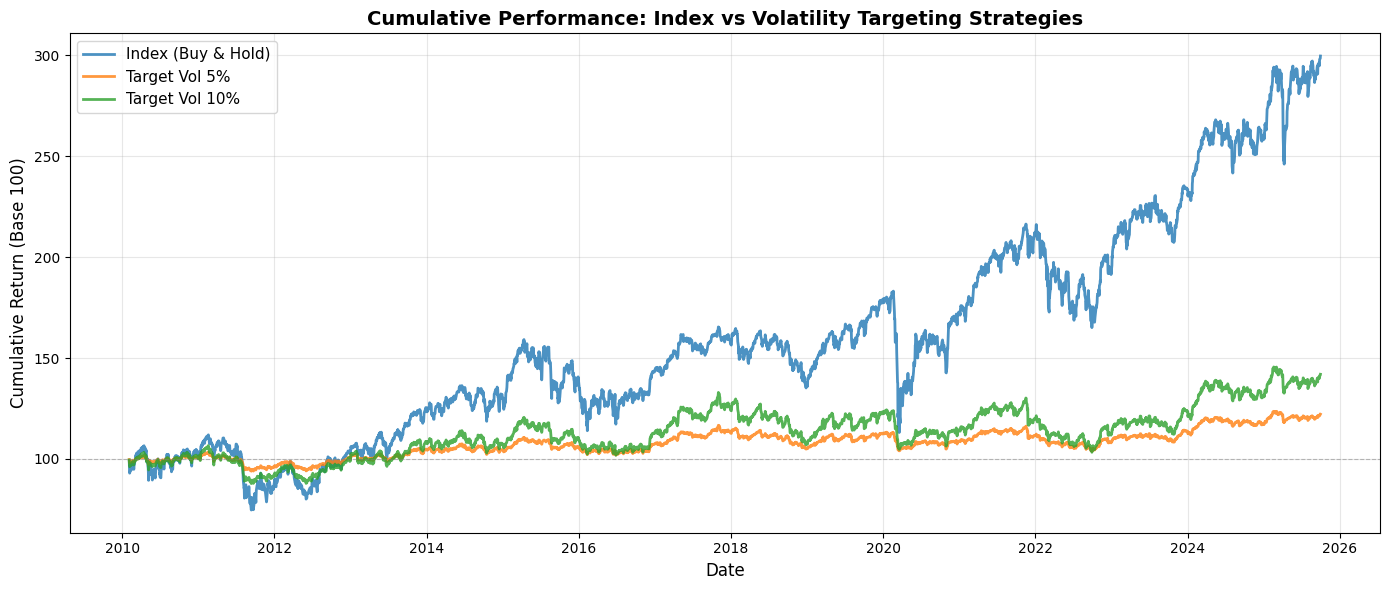

In [ ]:
# Plot cumulative returns
fig, ax = plt.subplots(figsize=(14, 6))

dates = [pd.Timestamp(d) for d in price_df_clean['date']]

ax.plot(dates, price_df_clean['cumret_index'], label='Index (Buy & Hold)', linewidth=2, alpha=0.8)
ax.plot(dates, price_df_clean['cumret_5pct'], label='Target Vol 5%', linewidth=2, alpha=0.8)
ax.plot(dates, price_df_clean['cumret_10pct'], label='Target Vol 10%', linewidth=2, alpha=0.8)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (Base 100)', fontsize=12)
ax.set_title('Cumulative Performance: Index vs Volatility Targeting Strategies', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()


### 4.2 Rolling Realized Volatility (21-day)


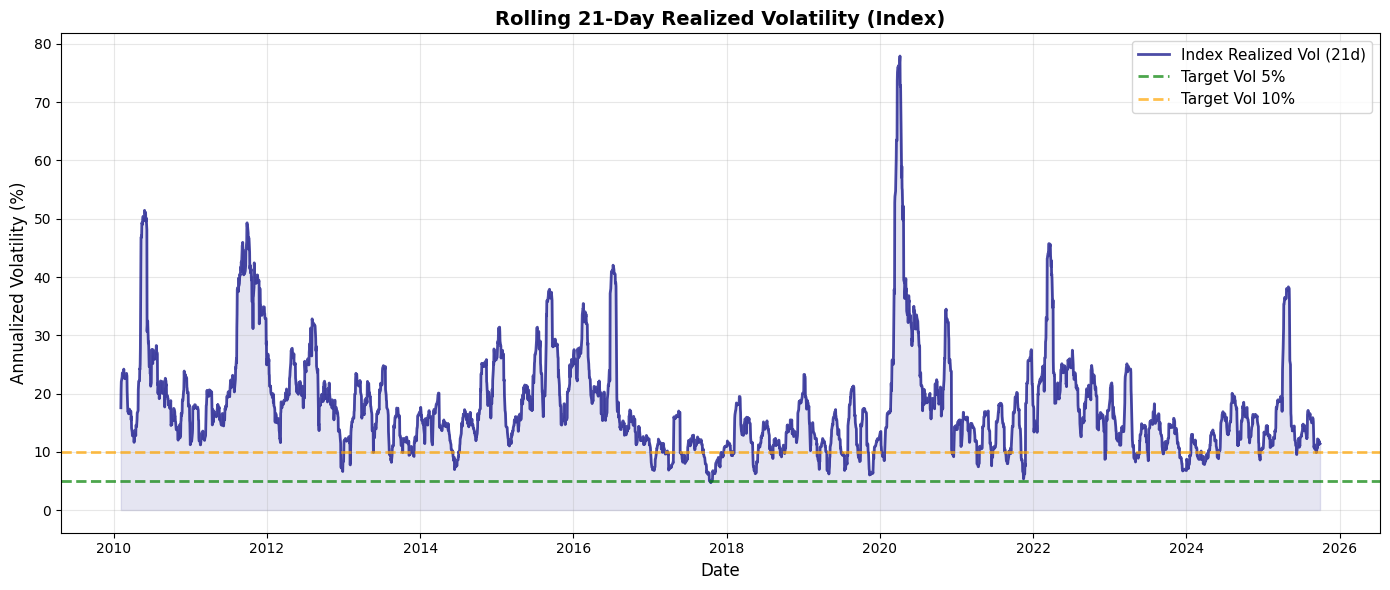

In [ ]:
# Plot realized volatility over time
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates, price_df_clean['realized_vol'] * 100, label='Index Realized Vol (21d)', 
        linewidth=2, color='navy', alpha=0.7)
ax.axhline(y=TARGET_VOL_5 * 100, color='green', linestyle='--', linewidth=2, 
           label='Target Vol 5%', alpha=0.7)
ax.axhline(y=TARGET_VOL_10 * 100, color='orange', linestyle='--', linewidth=2, 
           label='Target Vol 10%', alpha=0.7)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Annualized Volatility (%)', fontsize=12)
ax.set_title('Rolling 21-Day Realized Volatility (Index)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.fill_between(dates, 0, price_df_clean['realized_vol'] * 100, alpha=0.1, color='navy')

plt.tight_layout()
plt.show()


### 4.3 Position Sizing Over Time


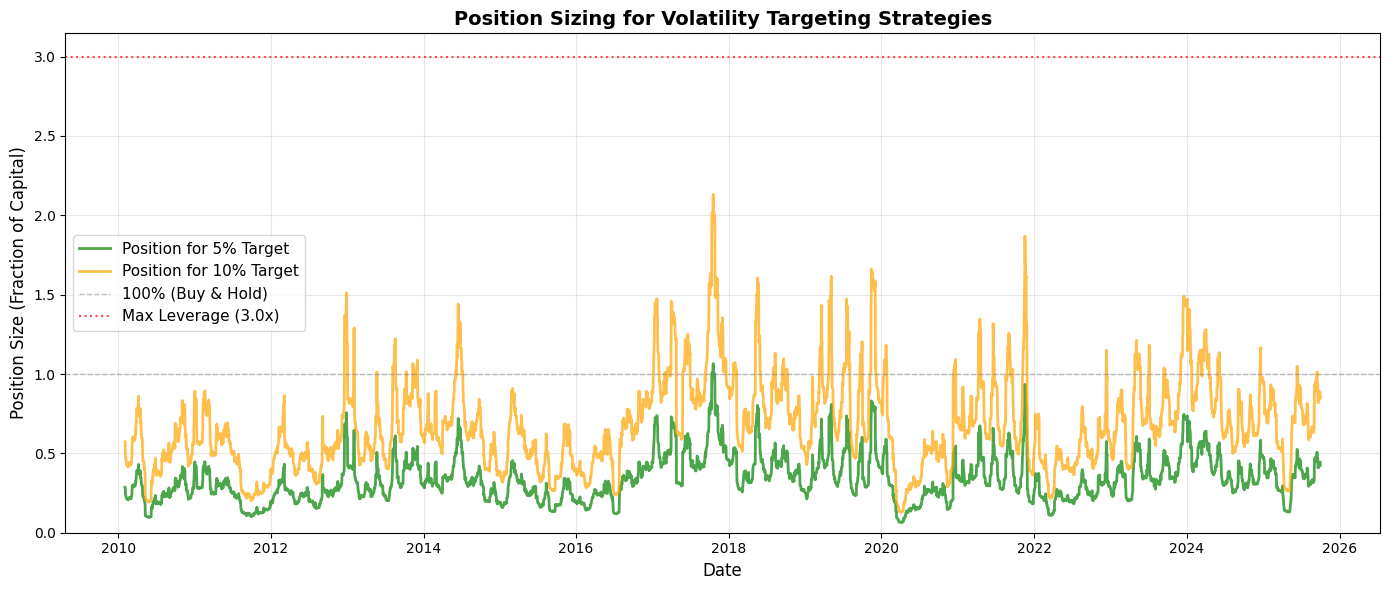

In [ ]:
# Plot position sizes
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates, price_df_clean['position_5pct_lag'], label='Position for 5% Target', 
        linewidth=2, alpha=0.7, color='green')
ax.plot(dates, price_df_clean['position_10pct_lag'], label='Position for 10% Target', 
        linewidth=2, alpha=0.7, color='orange')
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='100% (Buy & Hold)')
ax.axhline(y=MAX_LEVERAGE, color='red', linestyle=':', linewidth=1.5, alpha=0.7, label=f'Max Leverage ({MAX_LEVERAGE}x)')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Position Size (Fraction of Capital)', fontsize=12)
ax.set_title('Position Sizing for Volatility Targeting Strategies', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()


### 4.4 Distribution of Daily Returns


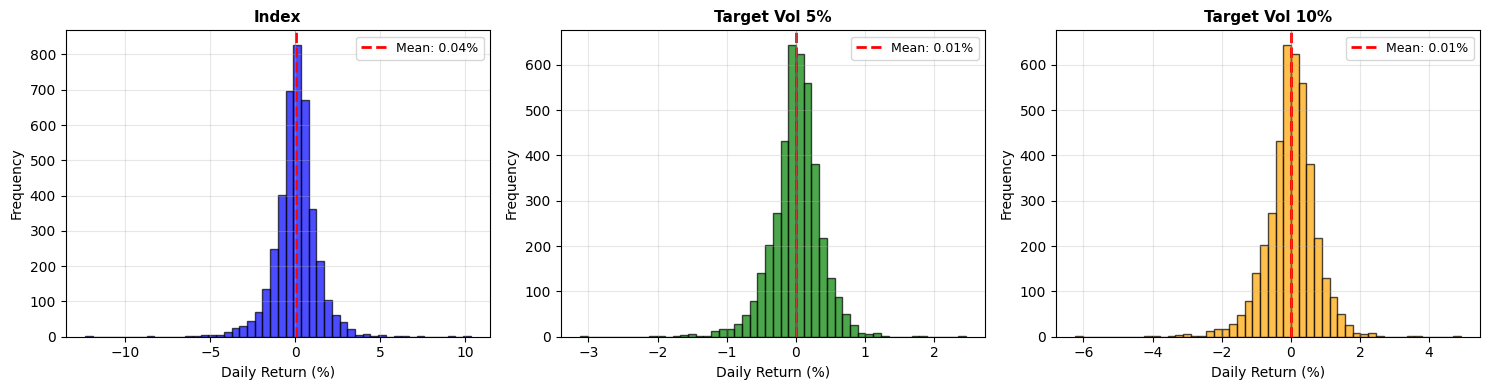

In [ ]:
# Plot return distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

returns_data = [
    (price_df_clean['return'] * 100, 'Index', 'blue'),
    (price_df_clean['return_5pct'] * 100, 'Target Vol 5%', 'green'),
    (price_df_clean['return_10pct'] * 100, 'Target Vol 10%', 'orange')
]

for idx, (returns, title, color) in enumerate(returns_data):
    ax = axes[idx]
    ax.hist(returns, bins=50, alpha=0.7, color=color, edgecolor='black')
    ax.axvline(returns.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {returns.mean():.2f}%')
    ax.axvline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Daily Return (%)', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Rolling Realized Volatility for All Strategies


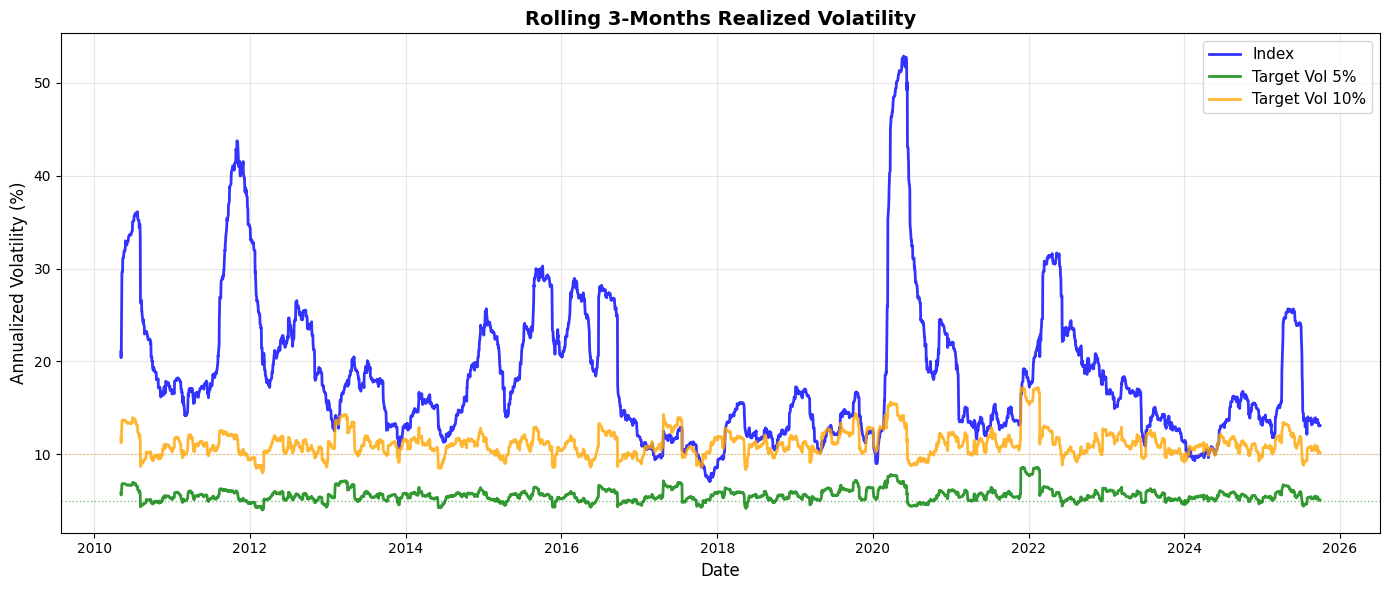


Note: Rolling volatility calculated over 63 days (~3 months) for smoother visualization


In [ ]:
# Calculate rolling realized vol for all three strategies
ROLL_VOL_WINDOW = 63  # 3 months for smoother visualization

price_df_clean['rolling_vol_index'] = price_df_clean['return'].rolling(window=ROLL_VOL_WINDOW).std() * np.sqrt(TRADING_DAYS) * 100
price_df_clean['rolling_vol_5pct'] = price_df_clean['return_5pct'].rolling(window=ROLL_VOL_WINDOW).std() * np.sqrt(TRADING_DAYS) * 100
price_df_clean['rolling_vol_10pct'] = price_df_clean['return_10pct'].rolling(window=ROLL_VOL_WINDOW).std() * np.sqrt(TRADING_DAYS) * 100

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

dates_plot = [pd.Timestamp(d) for d in price_df_clean['date'].iloc[ROLL_VOL_WINDOW:]]

ax.plot(dates_plot, price_df_clean['rolling_vol_index'].iloc[ROLL_VOL_WINDOW:], 
        label='Index', linewidth=2, alpha=0.8, color='blue')
ax.plot(dates_plot, price_df_clean['rolling_vol_5pct'].iloc[ROLL_VOL_WINDOW:], 
        label='Target Vol 5%', linewidth=2, alpha=0.8, color='green')
ax.plot(dates_plot, price_df_clean['rolling_vol_10pct'].iloc[ROLL_VOL_WINDOW:], 
        label='Target Vol 10%', linewidth=2, alpha=0.8, color='orange')

ax.axhline(y=TARGET_VOL_5 * 100, color='green', linestyle=':', linewidth=1, alpha=0.5)
ax.axhline(y=TARGET_VOL_10 * 100, color='orange', linestyle=':', linewidth=1, alpha=0.5)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Annualized Volatility (%)', fontsize=12)
ax.set_title(f'Rolling 3-Months Realized Volatility', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nNote: Rolling volatility calculated over {ROLL_VOL_WINDOW} days (~3 months) for smoother visualization")


## 6. Key Insights

### Result Interpretation

1. **Volatility Targeting**:
   - Target vol strategies dynamically adjust exposure
   - Reduce exposure during high volatility periods (crises)
   - Increase exposure during low volatility periods

2. **Risk/Return Trade-off**:
   - Target Vol 5%: lower volatility but also potentially lower returns
   - Target Vol 10%: higher exposure and higher variability
   - Buy & Hold: time-varying volatility, constant exposure

3. **Sharpe Ratio**:
   - Key metric for evaluating risk-adjusted efficiency
   - Volatility targeting can improve Sharpe in markets with time-varying volatility
   - Optimal target vol depends on investor's risk appetite

4. **Practical Implementation**:
   - Requires daily monitoring and rebalancing
   - Transaction costs not considered in this analysis
   - Leverage cap (3x) necessary to avoid excessive positions when vol is very low
   - Strategy works as a mechanical "buy low, sell high" mechanism based on volatility


## 7. LaTeX Beamer Slide

```latex
\begin{frame}{Volatility Targeting}

\textbf{Idea:} Scale portfolio exposure to maintain constant volatility over time.

\vspace{0.5cm}

\textbf{Formula:}
$$
w_t = \frac{\sigma_{\text{target}}}{\sigma_{\text{realized},t}}
$$

\vspace{0.3cm}

High volatility $\rightarrow$ reduce exposure \quad | \quad Low volatility $\rightarrow$ increase exposure

\end{frame}
```
